Setup & Load All Results

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
df = pd.read_csv('data/online_retail_II.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Rebuild RFM
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalAmount', 'sum')
).reset_index()

rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def assign_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Cannot Lose Them'
    elif r <= 2 and f <= 2:
        return 'Lost Customers'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print("ALL DATA LOADED AND RFM REBUILT!\n")
print(f"   Total Customers : {len(rfm):,}")
print(f"   Total Revenue   : £{rfm['Monetary'].sum():,.2f}")

ALL DATA LOADED AND RFM REBUILT!

   Total Customers : 5,414
   Total Revenue   : £10,673,082.68


Insight Engine

In [3]:
def generate_business_insights(df, rfm):
    insights = []
    warnings_list = []
    opportunities = []

    # REVENUE INSIGHTS
    total_revenue = rfm['Monetary'].sum()
    total_customers = len(rfm)

    # Champion insight
    champions = rfm[rfm['Segment'] == 'Champions']
    champ_revenue_pct = (champions['Monetary'].sum() / total_revenue) * 100
    insights.append({
        'category': 'Revenue',
        'icon': '💰',
        'title': 'Champions Drive Your Business',
        'insight': f"{len(champions)} Champions ({len(champions)/total_customers*100:.1f}% of customers) generate £{champions['Monetary'].sum():,.0f} — {champ_revenue_pct:.1f}% of total revenue.",
        'action': f"Reward these {len(champions)} customers with exclusive offers to maintain loyalty."
    })

    # === WARNING INSIGHTS ===
    # Lost customers
    lost = rfm[rfm['Segment'] == 'Lost Customers']
    lost_revenue_potential = lost['Monetary'].mean() * len(lost)
    warnings_list.append({
        'category': 'Warning',
        'icon': '⚠️',
        'title': 'High Customer Churn Detected',
        'insight': f"{len(lost)} customers ({len(lost)/total_customers*100:.1f}%) are Lost. Potential revenue at risk: £{lost_revenue_potential:,.0f}.",
        'action': "Launch a win-back campaign with 20% discount for customers inactive over 6 months."
    })

    # At Risk
    at_risk = rfm[rfm['Segment'] == 'At Risk']
    warnings_list.append({
        'category': 'Warning',
        'icon': '🔴',
        'title': 'At-Risk Customers Need Immediate Action',
        'insight': f"{len(at_risk)} valuable customers are At Risk — they used to buy frequently but have gone quiet.",
        'action': f"Send personalized re-engagement emails to {len(at_risk)} at-risk customers this week."
    })

    # === OPPORTUNITY INSIGHTS ===
    # Potential Loyalists
    potential = rfm[rfm['Segment'] == 'Potential Loyalists']
    opportunities.append({
        'category': 'Opportunity',
        'icon': '🚀',
        'title': 'Potential Loyalists Ready to Upgrade',
        'insight': f"{len(potential)} Potential Loyalists are close to becoming Champions — they buy regularly but not enough.",
        'action': f"Offer loyalty points or bundle deals to convert {len(potential)} customers into Champions."
    })

    # Peak season
    df['Month'] = df['InvoiceDate'].dt.month
    monthly = df.groupby('Month')['TotalAmount'].sum()
    best_month = monthly.idxmax()
    worst_month = monthly.idxmin()
    month_names = {1:'January',2:'February',3:'March',4:'April',5:'May',6:'June',
                   7:'July',8:'August',9:'September',10:'October',11:'November',12:'December'}
    opportunities.append({
        'category': 'Opportunity',
        'icon': '📅',
        'title': 'Seasonal Revenue Opportunity',
        'insight': f"{month_names[best_month]} is your strongest month. {month_names[worst_month]} is weakest — revenue drops {((monthly[best_month]-monthly[worst_month])/monthly[best_month]*100):.0f}% compared to peak.",
        'action': f"Prepare campaigns in advance for {month_names[best_month]}. Run promotions in {month_names[worst_month]} to boost slow period."
    })

    # Forecast
    opportunities.append({
        'category': 'Forecast',
        'icon': '📈',
        'title': 'Next 90-Day Revenue Forecast',
        'insight': "Prophet model predicts £1,924,121 in revenue over the next 90 days (Dec 2011 — Mar 2012).",
        'action': "Stock inventory accordingly and allocate marketing budget to peak forecast days."
    })

    return insights, warnings_list, opportunities

insights, warnings_list, opportunities = generate_business_insights(df, rfm)

print("INSIGHT ENGINE COMPLETE!")
print(f"\n📊 Generated {len(insights)} Revenue Insights")
print(f"⚠️  Generated {len(warnings_list)} Warning Alerts")
print(f"🚀 Generated {len(opportunities)} Opportunities")
print("\nSAMPLE INSIGHT:\n")
print(f"{insights[0]['icon']} {insights[0]['title']}")
print(f"   {insights[0]['insight']}")
print(f"   Action: {insights[0]['action']}")

INSIGHT ENGINE COMPLETE!

📊 Generated 1 Revenue Insights
⚠️  Generated 2 Warning Alerts
🚀 Generated 3 Opportunities

SAMPLE INSIGHT:

💰 Champions Drive Your Business
   1119 Champions (20.7% of customers) generate £7,837,051 — 73.4% of total revenue.
   Action: Reward these 1119 customers with exclusive offers to maintain loyalty.


Insight Dashboard

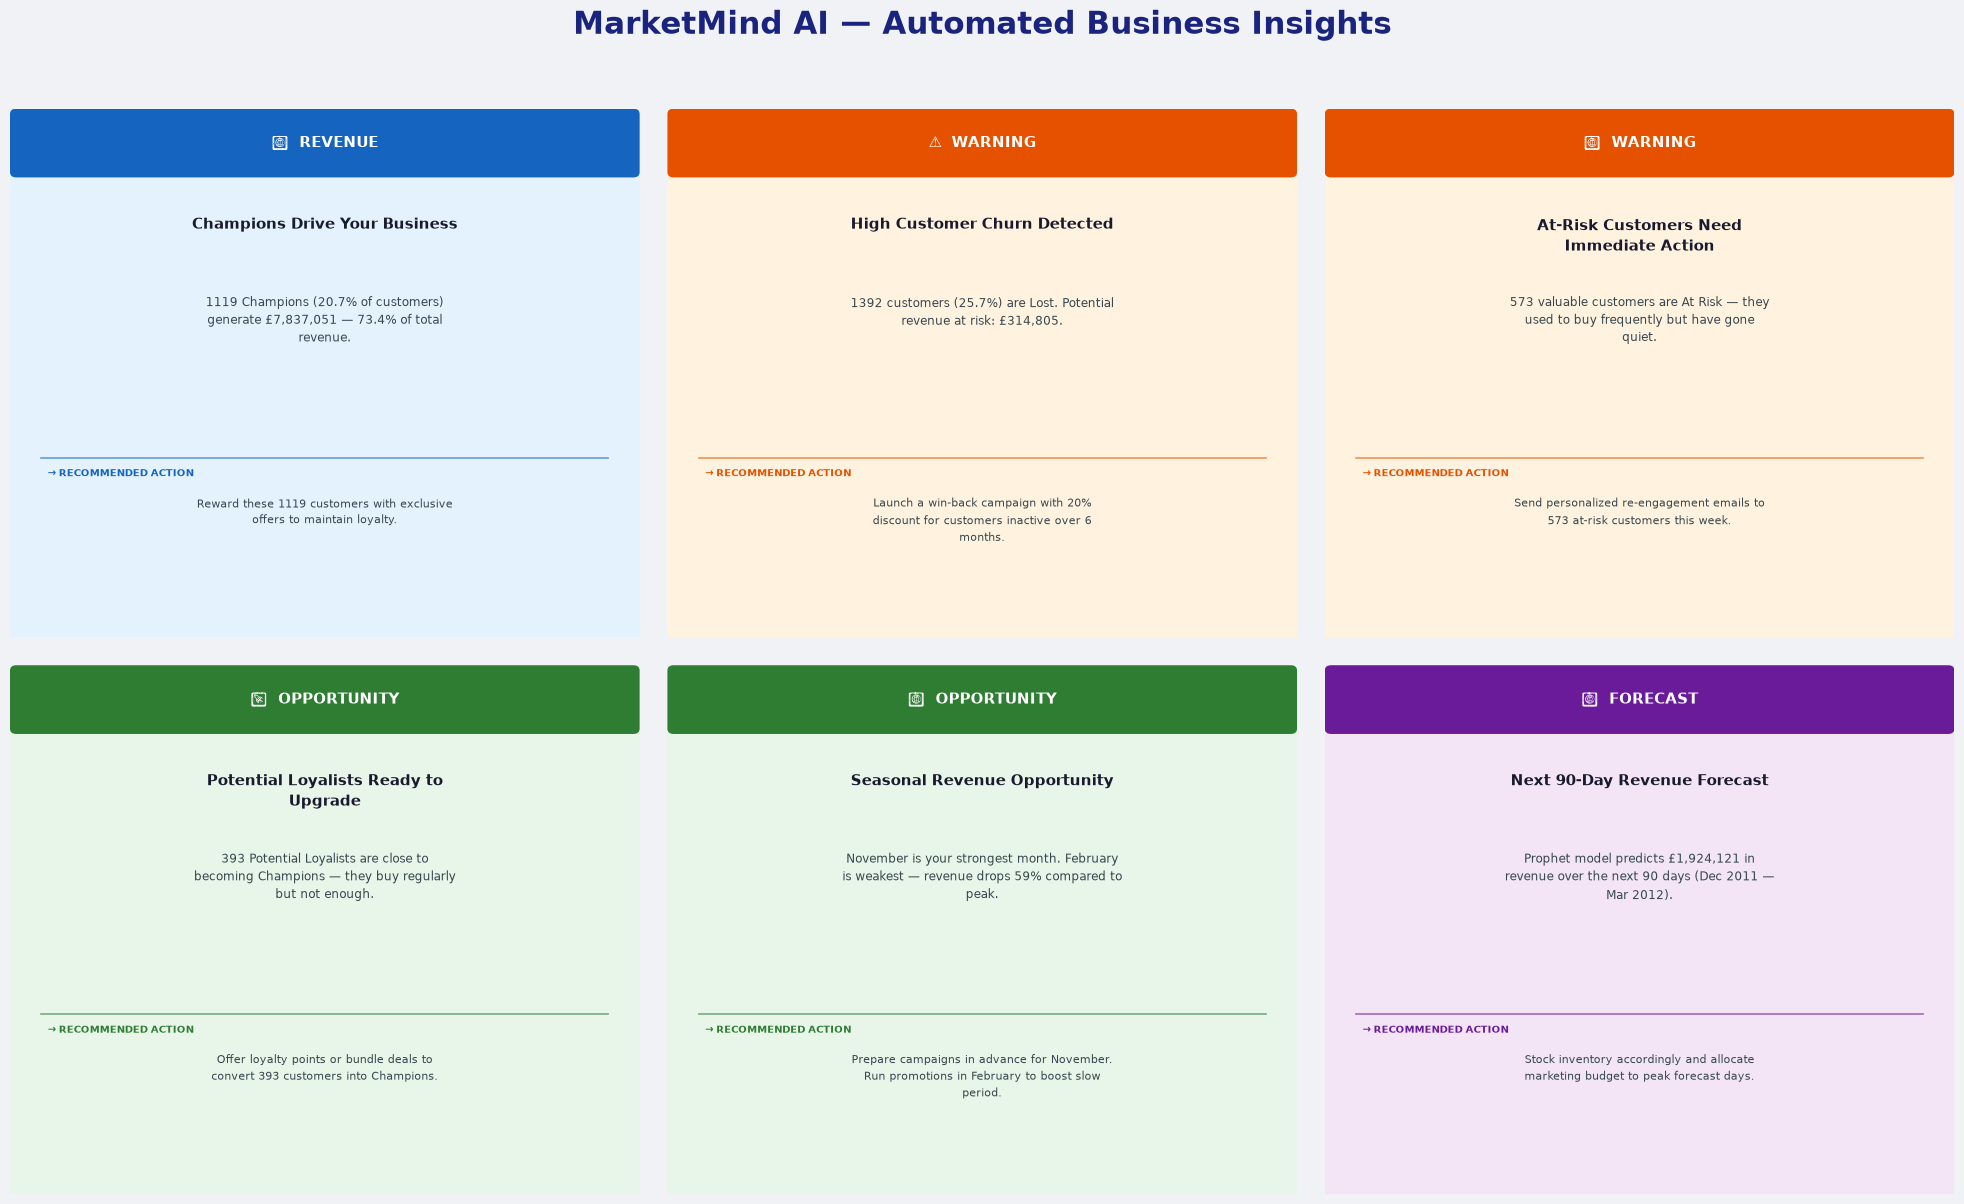

Insight Dashboard Saved!


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.patch.set_facecolor('#F0F2F5')
fig.suptitle('MarketMind AI — Automated Business Insights',
             fontsize=22, fontweight='bold', y=1.01, color='#1A237E')

all_items = insights + warnings_list + opportunities

category_styles = {
    'Revenue':     {'bg': '#E3F2FD', 'border': '#1565C0', 'badge_bg': '#1565C0'},
    'Warning':     {'bg': '#FFF3E0', 'border': '#E65100', 'badge_bg': '#E65100'},
    'Opportunity': {'bg': '#E8F5E9', 'border': '#2E7D32', 'badge_bg': '#2E7D32'},
    'Forecast':    {'bg': '#F3E5F5', 'border': '#6A1B9A', 'badge_bg': '#6A1B9A'}
}

import textwrap

for idx, (ax, item) in enumerate(zip(axes.flat, all_items[:6])):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')

    style = category_styles.get(item['category'], 
                                {'bg': '#FFFFFF', 'border': '#333333', 'badge_bg': '#333333'})

    # Card background
    card = mpatches.FancyBboxPatch(
        (0.1, 0.1), 9.8, 9.8,
        boxstyle="round,pad=0.2",
        facecolor=style['bg'],
        edgecolor=style['border'],
        linewidth=3,
        zorder=1
    )
    ax.add_patch(card)

    # Top color bar
    top_bar = mpatches.FancyBboxPatch(
        (0.1, 8.8), 9.8, 1.1,
        boxstyle="round,pad=0.1",
        facecolor=style['badge_bg'],
        edgecolor='none',
        zorder=2
    )
    ax.add_patch(top_bar)

    # Icon + Category in top bar
    ax.text(5, 9.35,
            f"{item['icon']}  {item['category'].upper()}",
            fontsize=11, fontweight='bold',
            color='white', ha='center', va='center',
            zorder=3)

    # Title
    title_wrapped = textwrap.fill(item['title'], width=30)
    ax.text(5, 8.0,
            title_wrapped,
            fontsize=10.5, fontweight='bold',
            color='#1A1A2E', ha='center', va='top',
            linespacing=1.4, zorder=3)

    # Insight text
    insight_wrapped = textwrap.fill(item['insight'], width=42)
    ax.text(5, 6.5,
            insight_wrapped,
            fontsize=8.5, color='#37474F',
            ha='center', va='top',
            linespacing=1.5, zorder=3)

    # Divider line
    ax.plot([0.5, 9.5], [3.4, 3.4],
            color=style['border'],
            linewidth=1.2, alpha=0.6, zorder=3)

    # Action label
    ax.text(0.6, 3.2,
            "→ RECOMMENDED ACTION",
            fontsize=7.5, fontweight='bold',
            color=style['border'], va='top', zorder=3)

    # Action text
    action_wrapped = textwrap.fill(item['action'], width=42)
    ax.text(5, 2.7,
            action_wrapped,
            fontsize=8, color='#37474F',
            ha='center', va='top',
            linespacing=1.5, zorder=3)

plt.tight_layout(pad=2.0)
plt.savefig('automated_insights.png', dpi=150,
            bbox_inches='tight', facecolor='#F0F2F5')
plt.show()
print("Insight Dashboard Saved!")